In [1]:
import pandas as pd 
import numpy as np
from collections import defaultdict
import sys
sys.path.append('/Users/fido_josephine/Documents/New-Fraud-Rules/fraud')
from modules.distance_finder import lev_win_multi, lev_win, lev_pos_win, lev_win_multi_pos, lev_win_pos_ind
df = pd.read_csv('IOS Fraud UG  (1).csv')
df['SURVEY_DATE'] = pd.to_datetime(df['TIME'])

In [2]:
df.head()

,TIME,HASH4,HASH5,PLATFORM,GROUPS,FRAUD_AREA,CLIENT_ID,ADDRESS,AGE,AIRTEL_WALLET,...,EMPLOYMENT,INCOME_VALUE,INDUSTRY,POSITION,POSLEN,REFERENCE1_PHONE_NUMBER,DISIBURSED,LOANAMOUNT,DR1,SURVEY_DATE
0,2025-02-01 00:00:00.000,kxvu,kxvu3,ios,CG,0,561324958,ngomba ruzinga,57,True,...,Employed full-time,"700,001 - 1,000,000 UGX",Construction,Truck driver,13,256772404867,1,45000.0,1,2025-02-01
1,2025-03-01 00:00:00.000,kxvu,kxvud,ios,CG,0,823318285,Ruhaama 2,47,True,...,Employed full-time,"700,001 - 1,000,000 UGX",Trade - Wholesale,Sales manager,14,256782667312,1,45000.0,1,2025-03-01
2,2025-03-01 00:00:00.000,kxvg,kxvge,ios,CG,0,31912050,kagarama rwakashaka,23,True,...,Employed full-time,"700,001 - 1,000,000 UGX",Trade - Wholesale,Sales manager,14,256740892947,1,45000.0,1,2025-03-01
3,2025-01-01 00:00:00.000,s8j3,s8j3s,ios,CG,0,59562690,nyakasanga road,61,False,...,Self-employed,"350,001 - 700,000 UGX",Agriculture,Farmer,6,256777573716,1,45000.0,1,2025-01-01
4,2025-01-01 00:00:00.000,kxyr,kxyr8,ios,CG,0,283642761,6th street,27,False,...,Self-employed,"700,001 - 1,000,000 UGX",Agriculture,farmer,6,256776998329,1,45000.0,1,2025-01-01


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   TIME                     649 non-null    object        
 1   HASH4                    649 non-null    object        
 2   HASH5                    649 non-null    object        
 3   PLATFORM                 649 non-null    object        
 4   GROUPS                   649 non-null    object        
 5   FRAUD_AREA               649 non-null    int64         
 6   CLIENT_ID                649 non-null    int64         
 7   ADDRESS                  649 non-null    object        
 8   AGE                      649 non-null    int64         
 9   AIRTEL_WALLET            649 non-null    bool          
 10  MTN_WALLET               649 non-null    bool          
 11  BANK_ACCOUNT             649 non-null    bool          
 12  HAS_ALTPHONE             649 non-nul

In [4]:
df['HASH'] = df['HASH4']
df['DISBURSED'] = df['DISIBURSED']
df = df.drop('TIME', axis=1)

In [5]:
records = []
for i in range(3, 6):
    for j in range(2, 10):
        output = defaultdict(list) 
        res = lev_pos_win(df, 15, j, i)
        output['dup_limit'] = j
        output['pos_sim'] = i
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)

output1 = pd.DataFrame(records)

In [6]:
output1

,dup_limit,pos_sim,n_surveys,n_disbursed,dr
0,2,3,79,79,0.974684
1,3,3,58,58,0.965517
2,4,3,51,51,0.960784
3,5,3,41,41,0.951220
4,6,3,34,34,0.941176
5,7,3,21,21,1.000000
6,8,3,20,20,1.000000
7,9,3,15,15,1.000000
8,2,4,102,102,0.941176
9,3,4,86,86,0.930233


In [7]:
import matplotlib.pyplot as plt

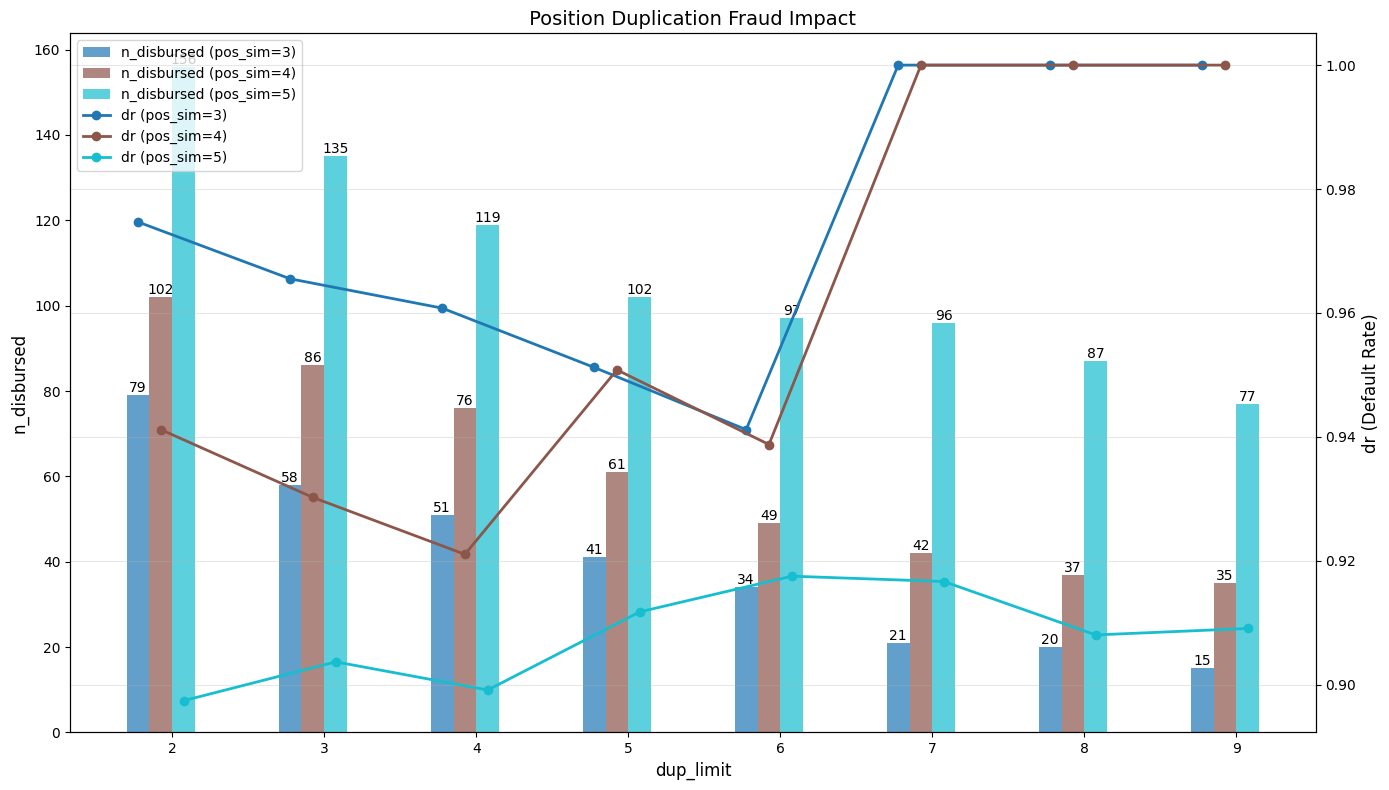

In [8]:
# Create the plot

fig, ax1 = plt.subplots(figsize=(14, 8))
ax2 = ax1.twinx()

# Define a colormap
colors = plt.cm.tab10(np.linspace(0, 1, len(output1['pos_sim'].unique())))
color_dict = {val: colors[i] for i, val in enumerate(sorted(output1['pos_sim'].unique()))}

# Plot bars and lines for each pos_sim value
for i, pos_sim in enumerate(sorted(output1['pos_sim'].unique())):
    subset = output1[output1['pos_sim'] == pos_sim]
    
    # Add slight offset to x positions for each pos_sim to avoid overlap
    width = 0.15
    offset = (i - len(output1['pos_sim'].unique())/2) * width
    
    # Plot n_disbursed as bars
    bars = ax1.bar(subset['dup_limit'] + offset, subset['n_disbursed'], 
                  width=width, color=color_dict[pos_sim], alpha=0.7,
                  label=f'n_disbursed (pos_sim={pos_sim})')
    
    # Plot dr as lines with markers
    line = ax2.plot(subset['dup_limit'] + offset, subset['dr'], 
                   linestyle='-', marker='o', color=color_dict[pos_sim],
                   alpha=1.0, linewidth=2,
                   label=f'dr (pos_sim={pos_sim})')
    for bar in bars: 
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height, f'{height}', ha='center', va='bottom', fontsize=10, color='black')


# Set labels and title
ax1.set_xlabel('dup_limit', fontsize=12)
ax1.set_ylabel('n_disbursed', fontsize=12, color='black')
ax2.set_ylabel('dr (Default Rate)', fontsize=12, color='black')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# Set title
plt.title(' Position Duplication Fraud Impact ', fontsize=14)

# Adjust layout and display
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

In [9]:

records = []
for i in range(2, 10):
    for j in (2, 5, 10, 15):
        output = defaultdict(list) 
        res = lev_win_multi(df, 15, i, 6, 2)
        output['add_sim'] = i
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)
results = pd.DataFrame(records)


/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_3576/1761060173.py:9: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_3576/1761060173.py:9: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_3576/1761060173.py:9: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_3576/1761060173.py:9: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br/rqk8kpt50q1_dkr0c2p_53lh0000gp/T/ipykernel_3576/1761060173.py:9: RuntimeWarning: invalid value encountered in scalar divide
  output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
/var/folders/br

In [10]:
results

,add_sim,n_surveys,n_disbursed,dr
0,2,0,0,NaN
1,2,0,0,NaN
2,2,0,0,NaN
3,2,0,0,NaN
4,3,0,0,NaN
5,3,0,0,NaN
6,3,0,0,NaN
7,3,0,0,NaN
8,4,0,0,NaN
9,4,0,0,NaN


Position + Industry Duplication

In [18]:

records = []
for i in range(2, 10):
    for j in range(2, 6):
        output = defaultdict(list) 
        res = lev_win_pos_ind(df, 15, i,  j)
        output['pos_sim'] = i
        output['dup_limit'] = j
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)
results = pd.DataFrame(records)

In [19]:
results

,pos_sim,dup_limit,n_surveys,n_disbursed,dr
0,2,2,63,63,0.968254
1,2,3,45,45,0.955556
2,2,4,38,38,0.947368
3,2,5,28,28,0.928571
4,3,2,63,63,0.968254
5,3,3,45,45,0.955556
6,3,4,38,38,0.947368
7,3,5,28,28,0.928571
8,4,2,70,70,0.971429
9,4,3,47,47,0.957447


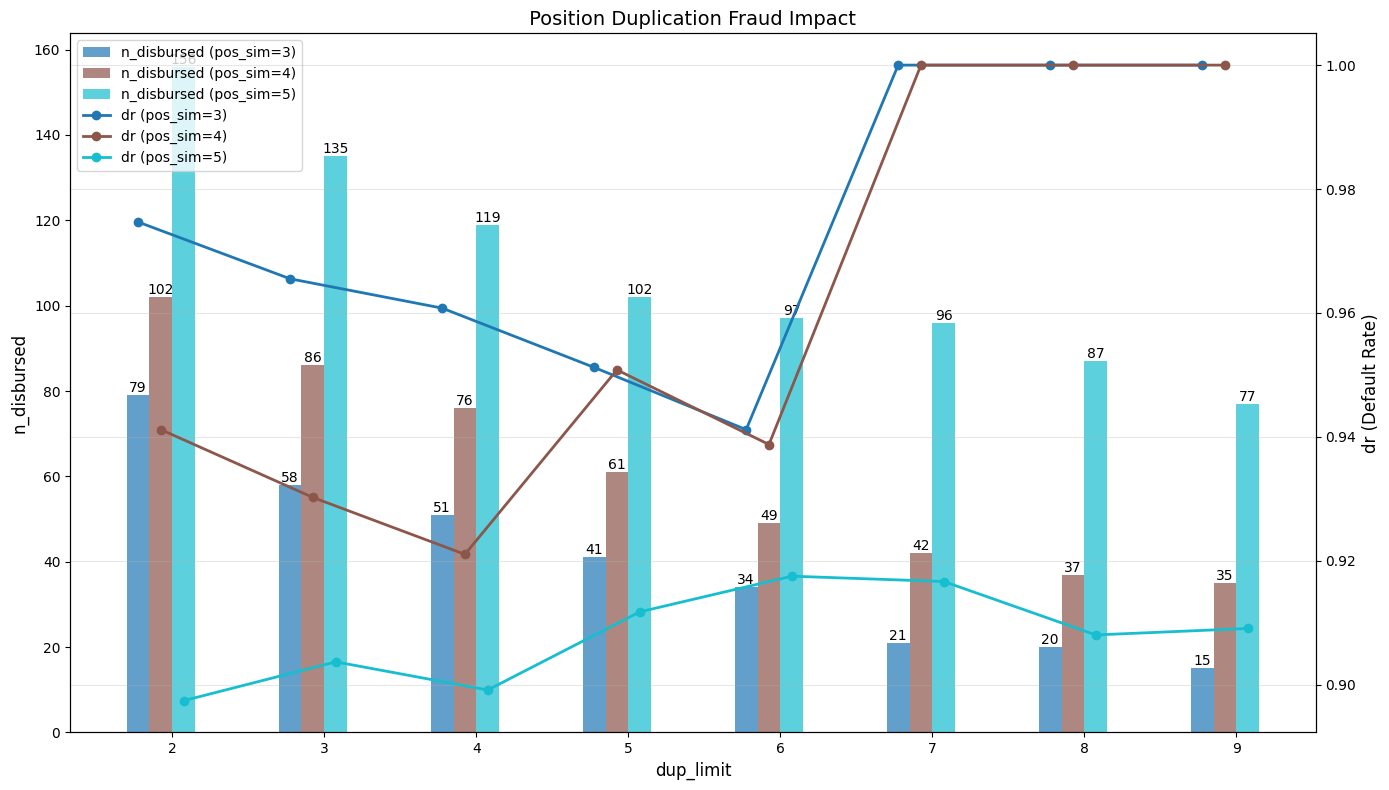

In [20]:
# Create the plot

fig, ax1 = plt.subplots(figsize=(14, 8))
ax2 = ax1.twinx()

# Define a colormap
colors = plt.cm.tab10(np.linspace(0, 1, len(output1['pos_sim'].unique())))
color_dict = {val: colors[i] for i, val in enumerate(sorted(output1['pos_sim'].unique()))}

# Plot bars and lines for each pos_sim value
for i, pos_sim in enumerate(sorted(output1['pos_sim'].unique())):
    subset = output1[output1['pos_sim'] == pos_sim]
    
    # Add slight offset to x positions for each pos_sim to avoid overlap
    width = 0.15
    offset = (i - len(output1['pos_sim'].unique())/2) * width
    
    # Plot n_disbursed as bars
    bars = ax1.bar(subset['dup_limit'] + offset, subset['n_disbursed'], 
                  width=width, color=color_dict[pos_sim], alpha=0.7,
                  label=f'n_disbursed (pos_sim={pos_sim})')
    
    # Plot dr as lines with markers
    line = ax2.plot(subset['dup_limit'] + offset, subset['dr'], 
                   linestyle='-', marker='o', color=color_dict[pos_sim],
                   alpha=1.0, linewidth=2,
                   label=f'dr (pos_sim={pos_sim})')
    for bar in bars: 
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height, f'{height}', ha='center', va='bottom', fontsize=10, color='black')


# Set labels and title
ax1.set_xlabel('dup_limit', fontsize=12)
ax1.set_ylabel('n_disbursed', fontsize=12, color='black')
ax2.set_ylabel('dr (Default Rate)', fontsize=12, color='black')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# Set title
plt.title(' Position Duplication Fraud Impact ', fontsize=14)

# Adjust layout and display
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()